Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_excel('premiums_young_with_gr.xlsx')
df.shape

(20096, 14)

In [3]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [4]:
df.columns =df.columns.str.replace(' ', '_').str.lower()

## Checking and fixing Null Values and duplicates

In [5]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## EDA

In [7]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [8]:
df[df['number_of_dependants'] < 0].shape
df['number_of_dependants'] = abs(df['number_of_dependants'])
df[df['number_of_dependants'] < 0].shape

(0, 14)

In [9]:
numeric_columns = df.select_dtypes(['float64', 'int64']).columns

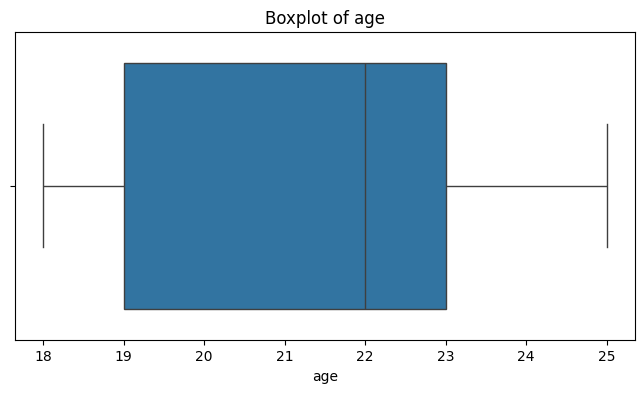

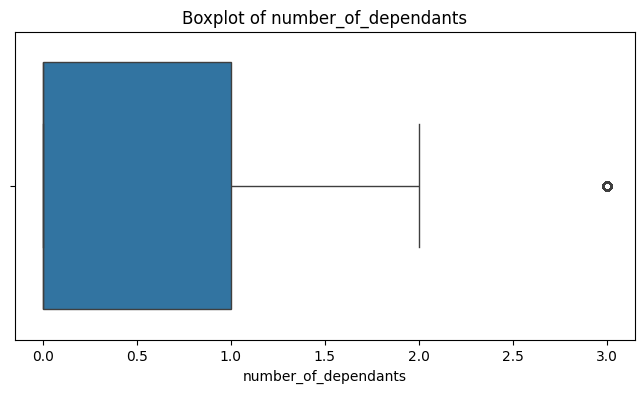

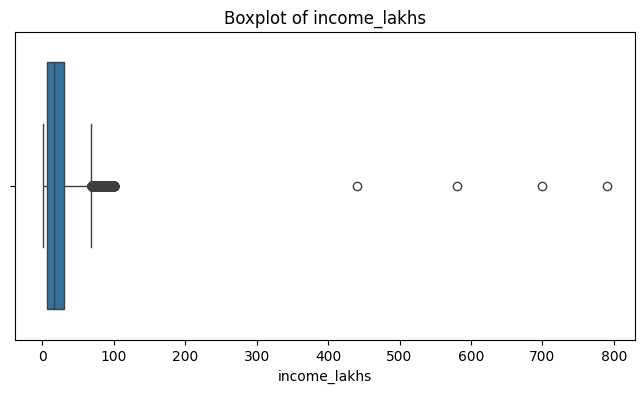

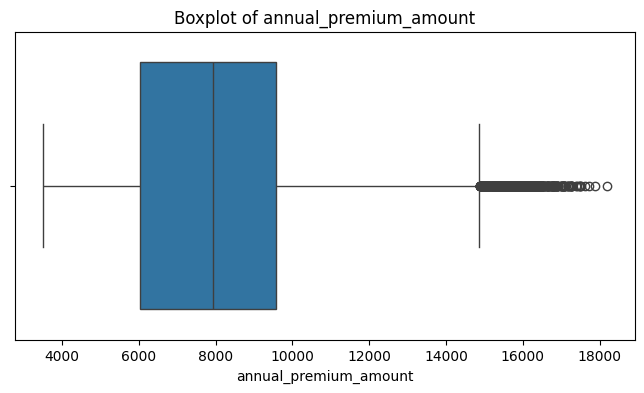

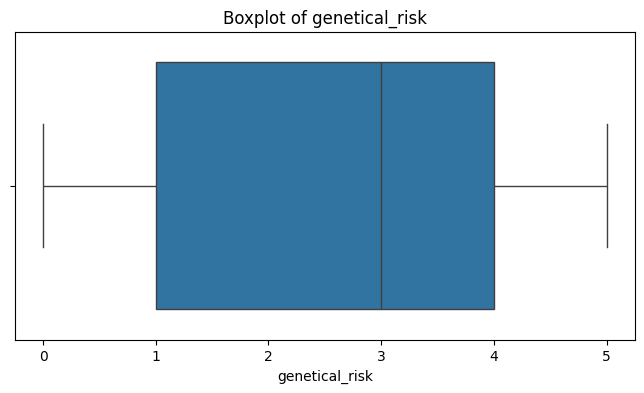

In [10]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [11]:
df[df['age'] > 100].shape
# df1 is after cleaning age column by removing outliers
df1 = df[df['age'] < 100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


<Axes: xlabel='income_lakhs', ylabel='Count'>

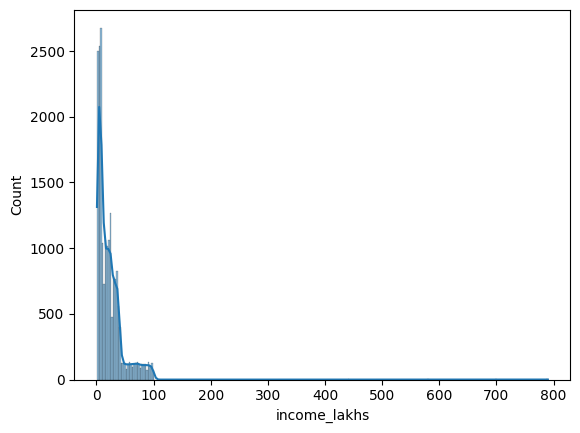

In [12]:
sns.histplot(df1['income_lakhs'], kde=True)

In [13]:
def get_quantile(col):
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [14]:
get_quantile('income_lakhs')

(np.float64(-31.5), np.float64(68.5))

In [15]:
# df2 is after cleaning income_lakhs column by removing outliers
df2 = df1[df1['income_lakhs'] <= df1['income_lakhs'].quantile(0.999)].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


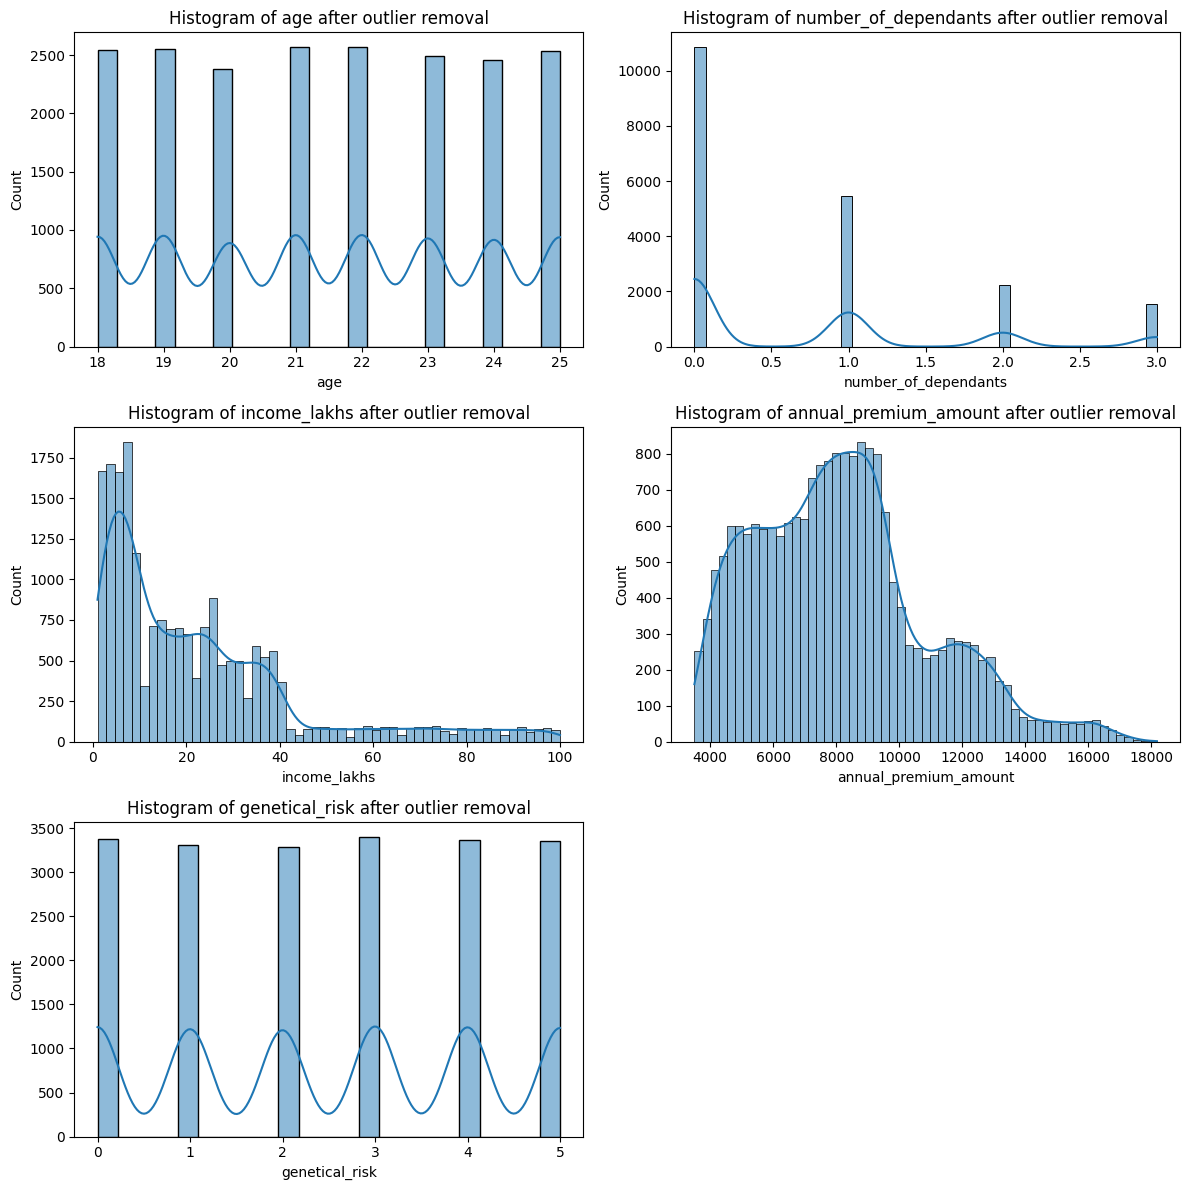

In [16]:
n_cols = 2
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col} after outlier removal')

# Hide extra empty plots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


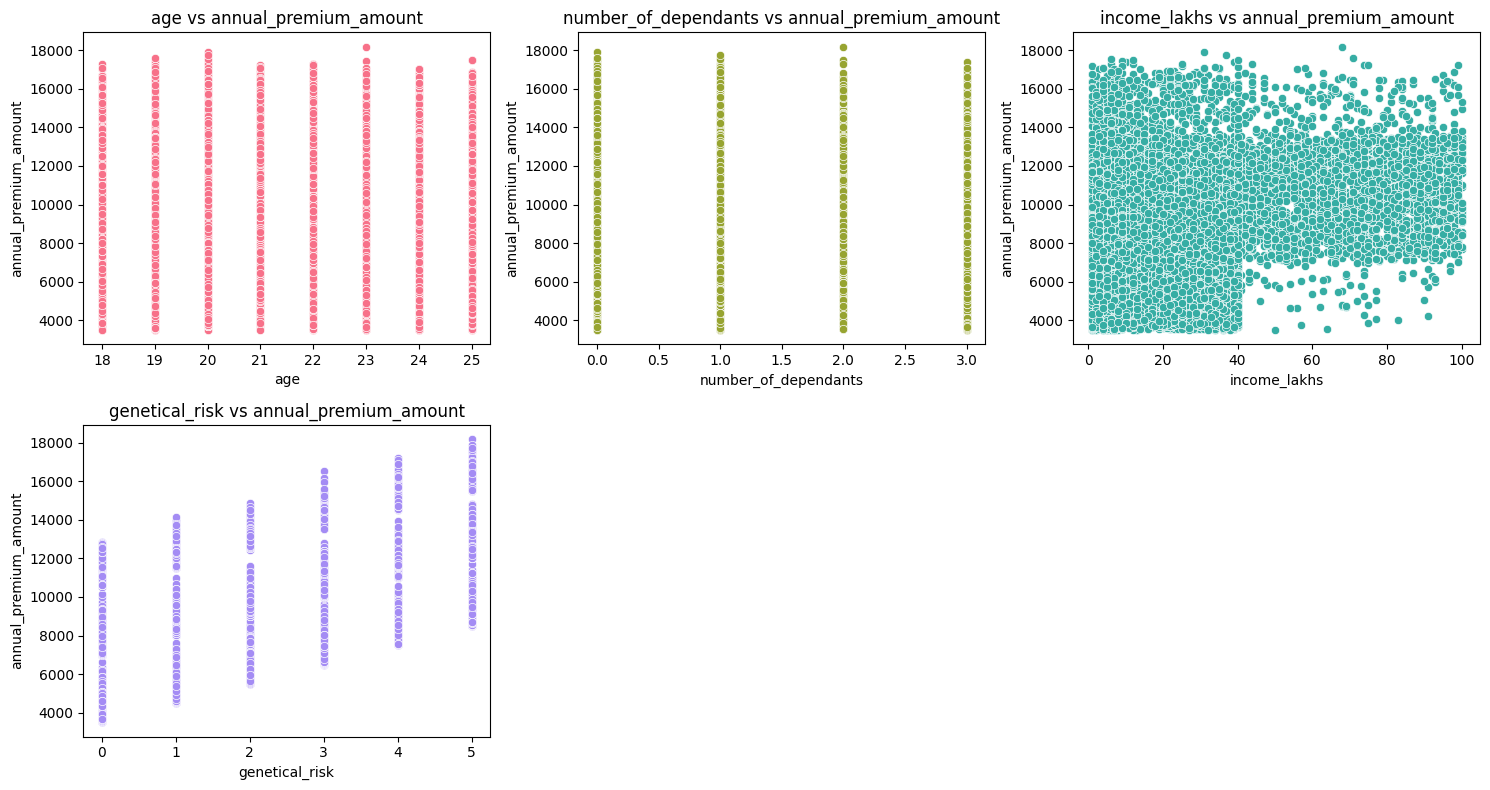

In [17]:
target = 'annual_premium_amount'

# Exclude target column
cols = [col for col in numeric_columns if col != target]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Color palette
colors = sns.color_palette("husl", len(cols))

for i, col in enumerate(cols):
    sns.scatterplot(
        x=df2[col],
        y=df2[target],
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(f'{col} vs {target}')

# Hide unused plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
df2['smoking_status'].unique()

<ArrowStringArray>
[       'Regular',     'No Smoking',     'Occasional',      'Smoking=0',
 'Does Not Smoke',    'Not Smoking']
Length: 6, dtype: str

In [19]:
df2['smoking_status'] = df2['smoking_status'].replace({'Smoking=0': 'No Smoking', 'Does Not Smoke': 'No Smoking','Not Smoking': 'No Smoking'})
df2['smoking_status'].unique()

<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str

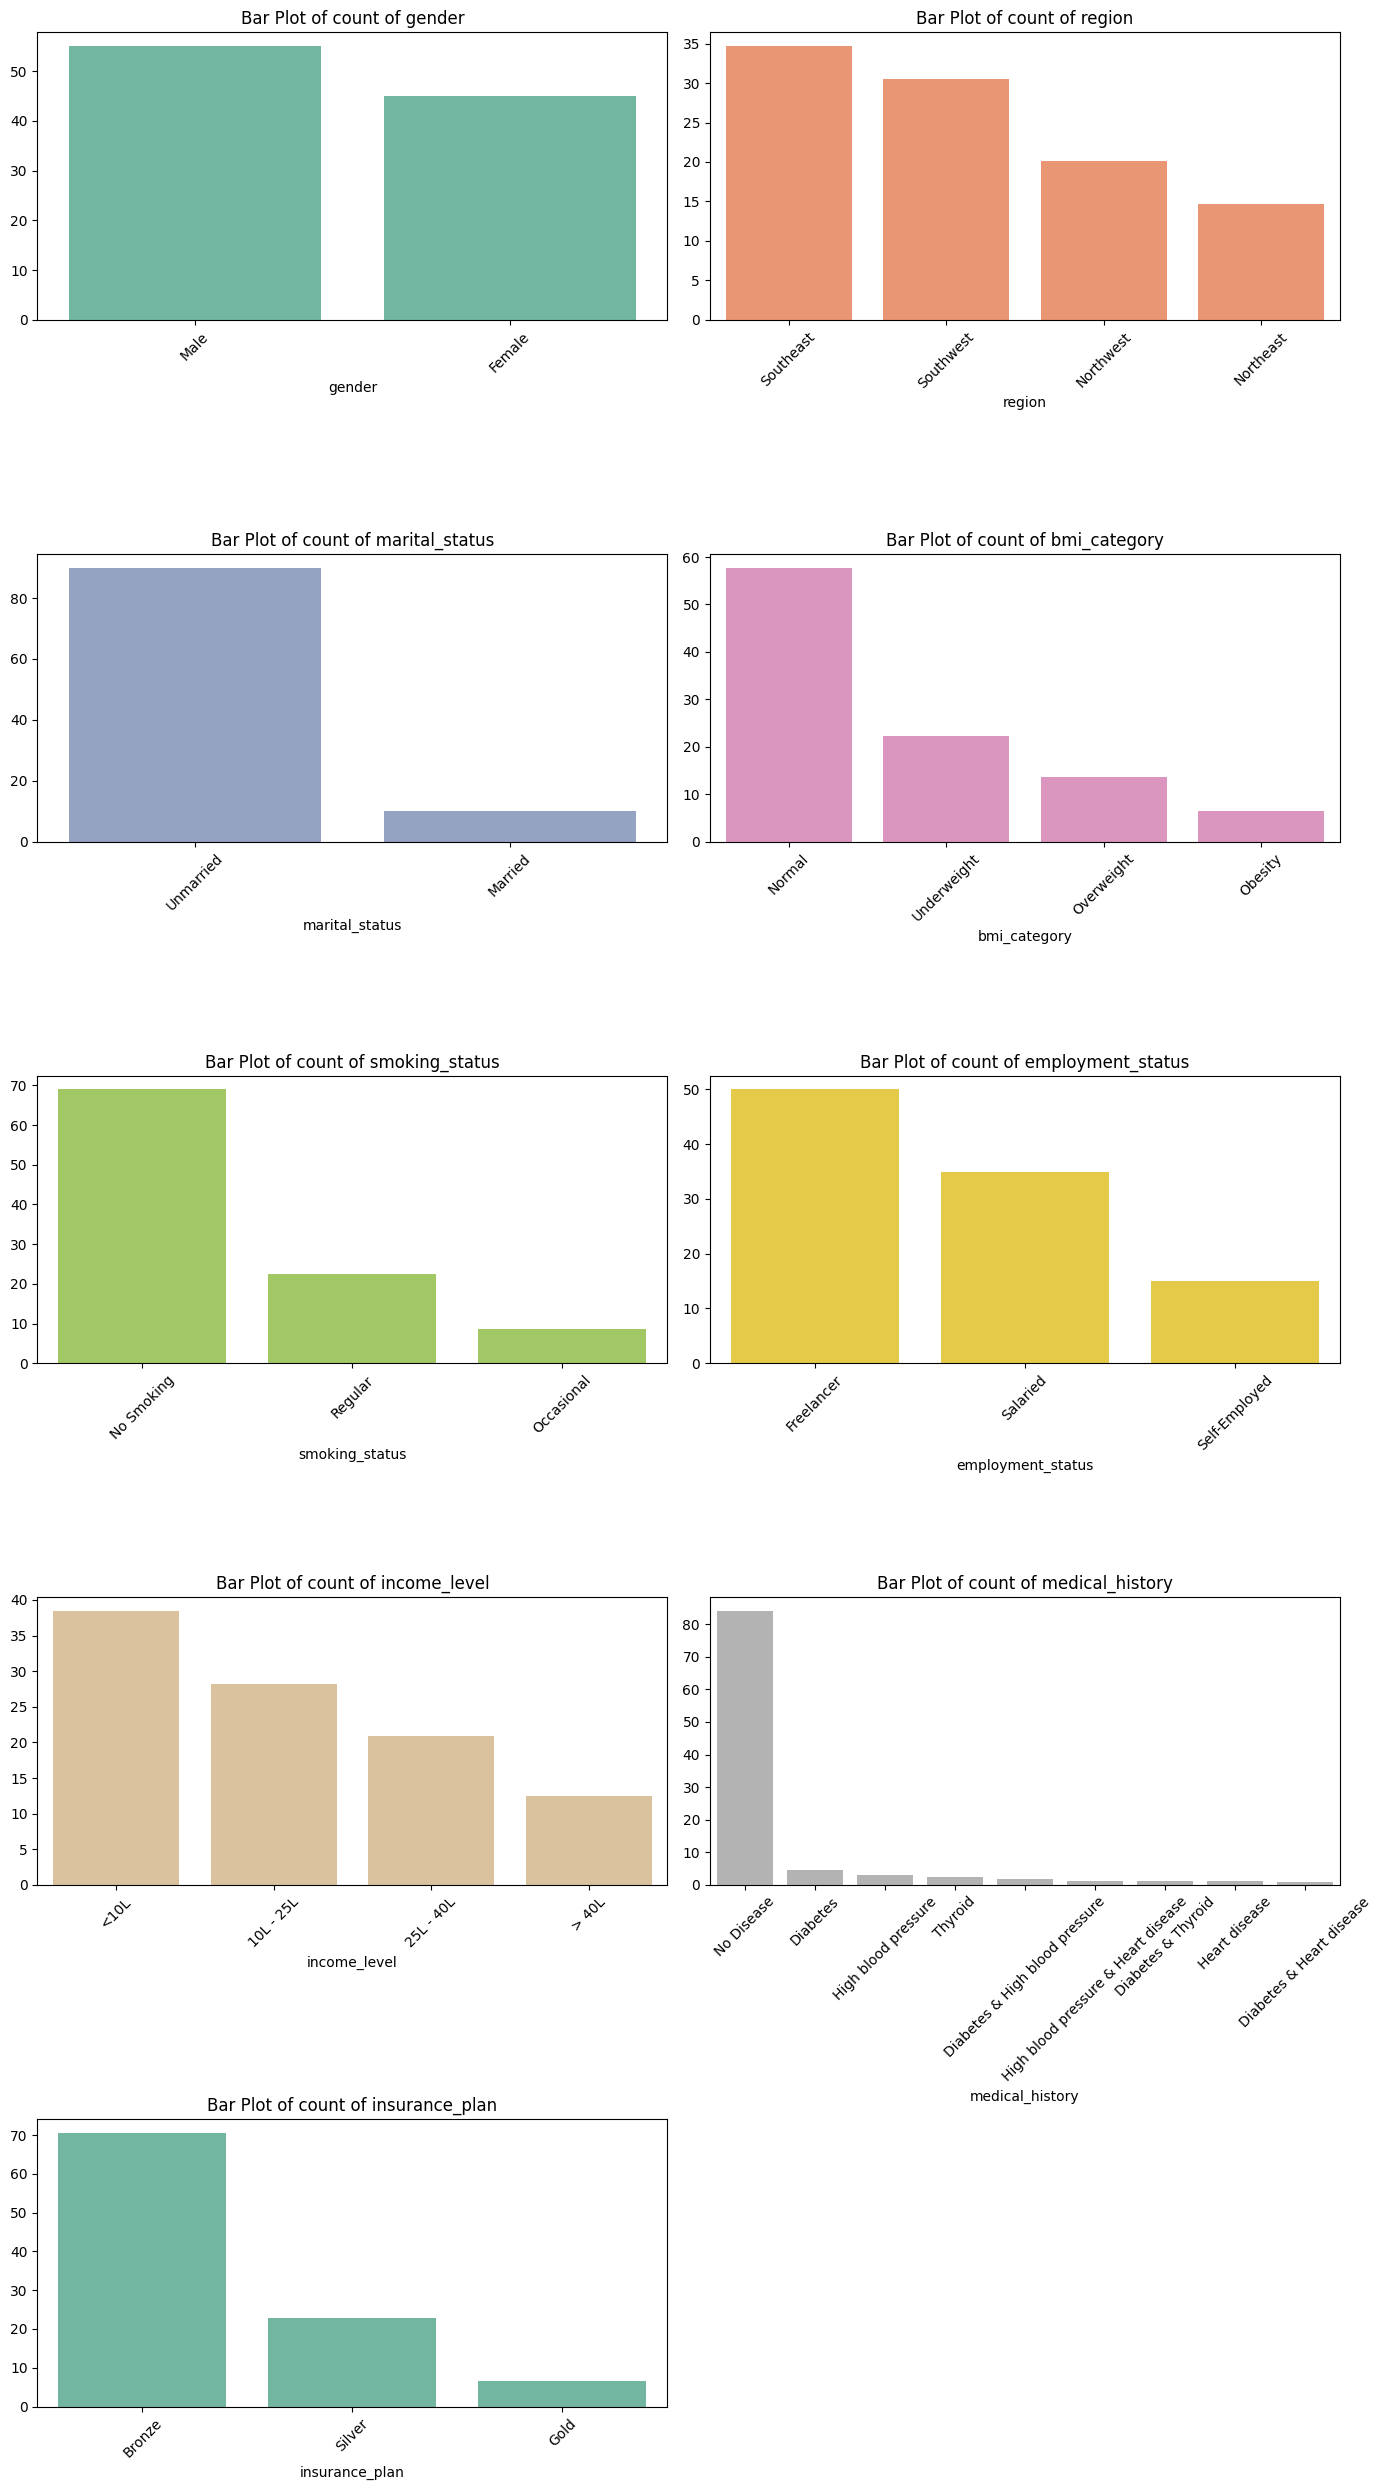

In [20]:
categorical_columns = df2.select_dtypes(include=['object','category','string']).columns


n_cols = 2
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Generate colors
colors = sns.color_palette("Set2", len(categorical_columns))

for i, col in enumerate(categorical_columns):
    
    pct_count = df2[col].value_counts(normalize=True) * 100
    
    sns.barplot(
        x=pct_count.index,
        y=pct_count.values,
        ax=axes[i],
        color=colors[i]
    )
    
    axes[i].set_title(f'Bar Plot of count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide extra empty plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [21]:
categorical_columns = df2.select_dtypes(
    include=['object', 'category', 'string']
).columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df2[col].unique())


Column: gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

Column: region
<ArrowStringArray>
['Northeast', 'Northwest', 'Southeast', 'Southwest']
Length: 4, dtype: str

Column: marital_status
<ArrowStringArray>
['Unmarried', 'Married']
Length: 2, dtype: str

Column: bmi_category
<ArrowStringArray>
['Overweight', 'Underweight', 'Normal', 'Obesity']
Length: 4, dtype: str

Column: smoking_status
<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str

Column: employment_status
<ArrowStringArray>
['Self-Employed', 'Freelancer', 'Salaried']
Length: 3, dtype: str

Column: income_level
<ArrowStringArray>
['> 40L', '<10L', '10L - 25L', '25L - 40L']
Length: 4, dtype: str

Column: medical_history
<ArrowStringArray>
[                'High blood pressure',                          'No Disease',
      'Diabetes & High blood pressure',            'Diabetes & Heart disease',
                            'Diabetes',                  'Diabetes & Thyroid',
     

In [23]:
numerical_columns = df2.select_dtypes(
    include=['int64', 'float64']
).columns

for col in numerical_columns:
    print(f"\nColumn: {col}")
    print(df2[col].unique())




Column: age
[18 22 21 25 20 19 23 24]

Column: number_of_dependants
[0 2 1 3]

Column: income_lakhs
[ 99   3  97  15  14  30   8   5  18  70  33  29   4   1  19  27  38  39
  20  36  16  92  22   9  57  24  49  52  90   2  10  21  88  11  13  25
  26  12   6  64  40  50  35  86  34  41  98  23   7  44  37  17  31  80
  81  32  46  85  58  42  28  61  78  75  51  65  43  84  71  73  66  53
  59  48  95  47  69  54  62  89  72  93  68  63  45  56  91  82  96  74
  79  67  77  60  76 100  87  55  83  94]

Column: annual_premium_amount
[13365 11050 11857 ...  6585  9783 14498]

Column: genetical_risk
[4 3 2 1 0 5]


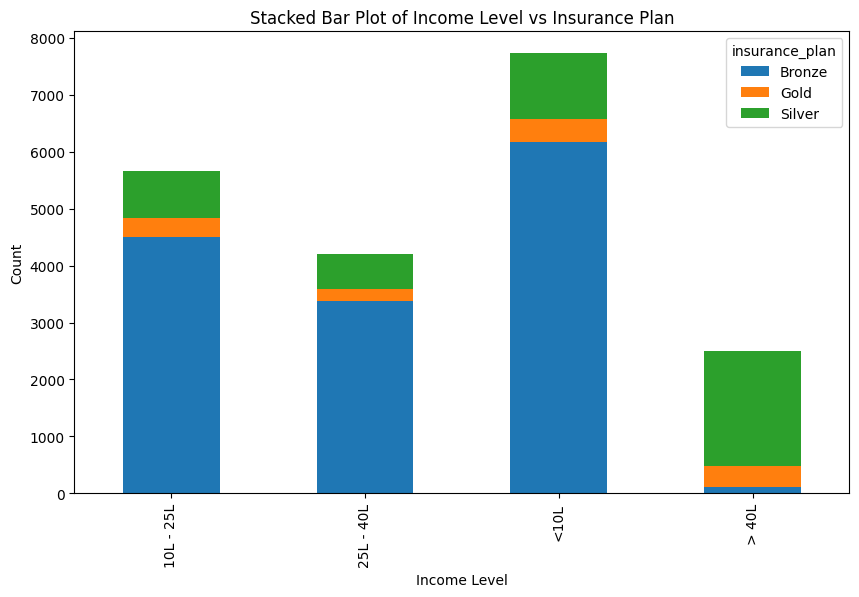

In [21]:
cross_tab = pd.crosstab(df2['income_level'],df2['insurance_plan'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Stacked Bar Plot of Income Level vs Insurance Plan')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

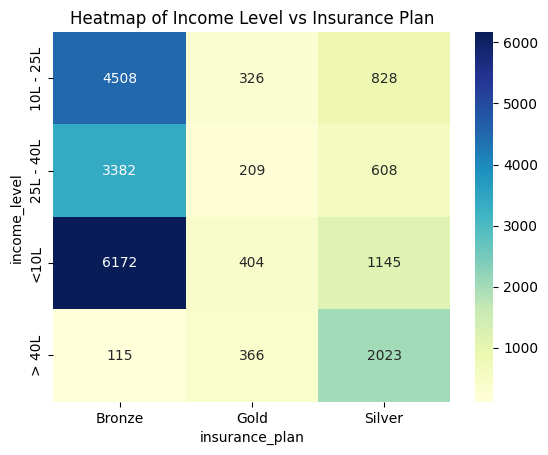

In [22]:
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Income Level vs Insurance Plan')
plt.show()

In [23]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

In [24]:
df2[['disease1','disease2']] = df2['medical_history'].str.split('&', expand=True).apply(lambda x: x.str.lower())
df2.fillna({'disease1': 'none', 'disease2': 'none'}, inplace=True)
for col in ['disease1', 'disease2']:
    df2[col] = df2[col].str.strip().str.lower()
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,none
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,none
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,none


In [25]:
df2['total_risk'] = 0
for disease in ['disease1', 'disease2']:
    df2['total_risk'] += df2[disease].map(risk_scores)
   
max_score = df2['total_risk'].max()
min_score = df2['total_risk'].min()
df2['normalized_risk_score'] = (df2['total_risk'] - min_score) / (max_score - min_score)
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,none,0,0.000000


## Encode Text Columns

In [26]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [27]:
df2.income_level.unique()

<StringArray>
['> 40L', '<10L', '10L - 25L', '25L - 40L']
Length: 4, dtype: str

In [28]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [29]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,none,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,2,no disease,none,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,1,no disease,none,...,1,0,1,0,1,0,0,0,0,0


In [30]:
df3.info()

<class 'pandas.DataFrame'>
Index: 20086 entries, 0 to 20095
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              20086 non-null  int64  
 1   number_of_dependants             20086 non-null  int64  
 2   income_level                     20086 non-null  int64  
 3   income_lakhs                     20086 non-null  int64  
 4   medical_history                  20086 non-null  str    
 5   insurance_plan                   20086 non-null  int64  
 6   annual_premium_amount            20086 non-null  int64  
 7   genetical_risk                   20086 non-null  int64  
 8   disease1                         20086 non-null  str    
 9   disease2                         20086 non-null  str    
 10  total_risk                       20086 non-null  int64  
 11  normalized_risk_score            20086 non-null  float64
 12  gender_Male                      2

In [31]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk'], axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,4,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,2,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,1,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


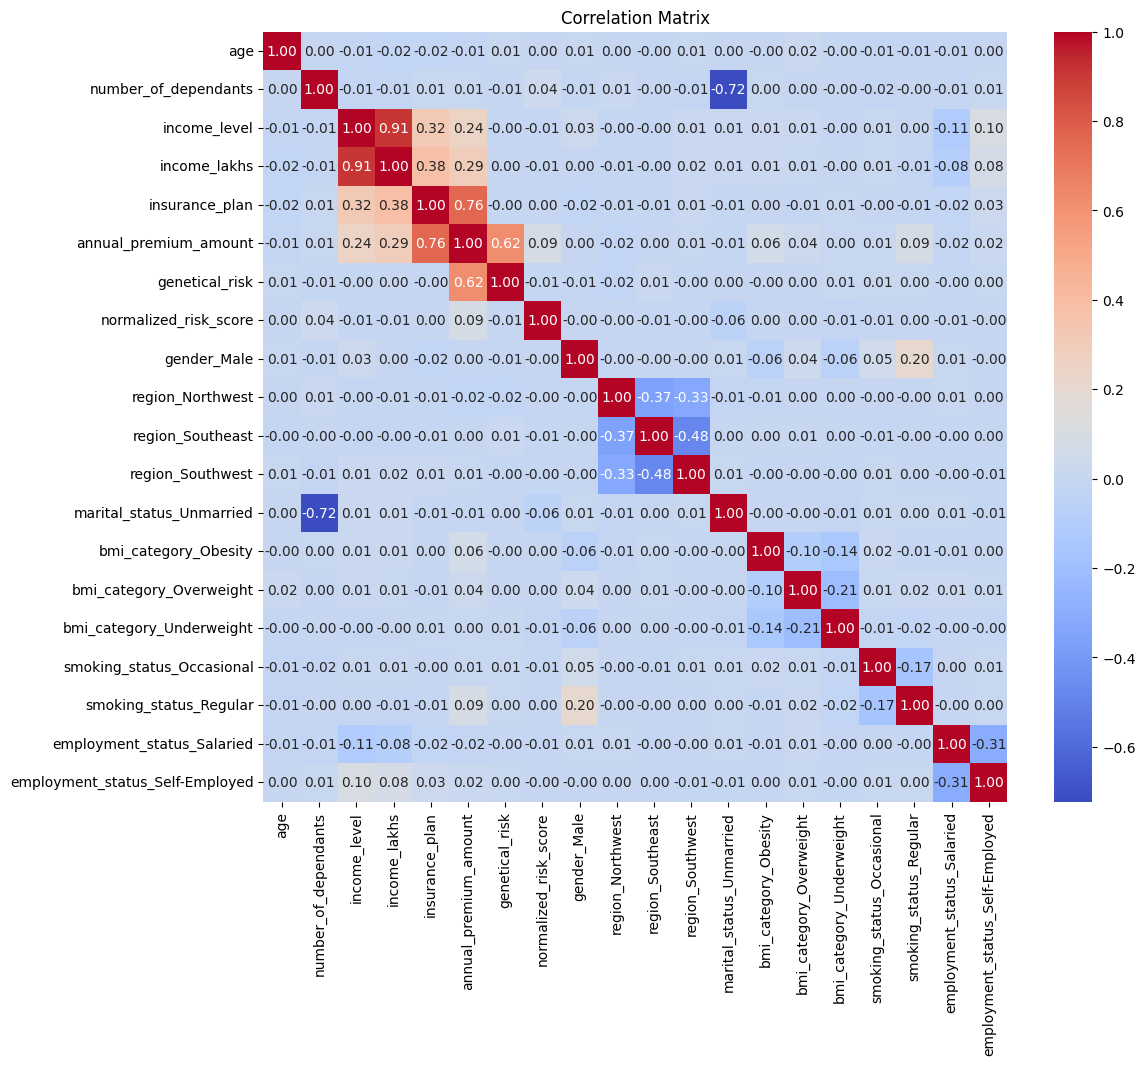

In [32]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [33]:
X = df4.drop('annual_premium_amount', axis=1)
y = df4['annual_premium_amount']
scaler = MinMaxScaler()
cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan','genetical_risk']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.500777,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.342037,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.600000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.800000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data


In [35]:
calculate_vif(X.drop('income_level', axis=1))

,feature,VIF
0,age,3.153255
1,number_of_dependants,1.927788
2,income_lakhs,2.294155
3,insurance_plan,1.587868
4,genetical_risk,2.981158
5,normalized_risk_score,1.154453
6,gender_Male,2.301658
7,region_Northwest,2.153423
8,region_Southeast,2.989301
9,region_Southwest,2.743932


In [36]:
X_reduced = X.drop('income_level', axis="columns")

## Model Training

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')
model = LinearRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training set size: 14060 samples
Testing set size: 6026 samples
Training R^2: 0.9883, Testing R^2: 0.9887


In [38]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.4f}, MSE: {mse:.4f}')

RMSE: 292.8009, MSE: 85732.3438


In [39]:
model.coef_

array([-7.22903185e+00,  1.95361819e+01, -1.26452776e+00,  7.00112526e+03,
        4.99698873e+03,  1.10914836e+03,  8.17798831e+00,  1.67735268e+00,
       -3.27532710e+00,  6.31709531e+00,  1.60689716e+01,  8.12844929e+02,
        4.00375598e+02,  1.07529819e+02,  2.05069661e+02,  6.10983280e+02,
        3.87836470e-02, -5.24201812e+00])

In [40]:
model.intercept_

np.float64(3978.8235284382536)

In [41]:
feature_importance = model.coef_
coeff_df = pd.DataFrame(feature_importance, index=X_reduced.columns, columns=['Coefficient'])
coeff_df = coeff_df.sort_values(by='Coefficient', ascending= True)

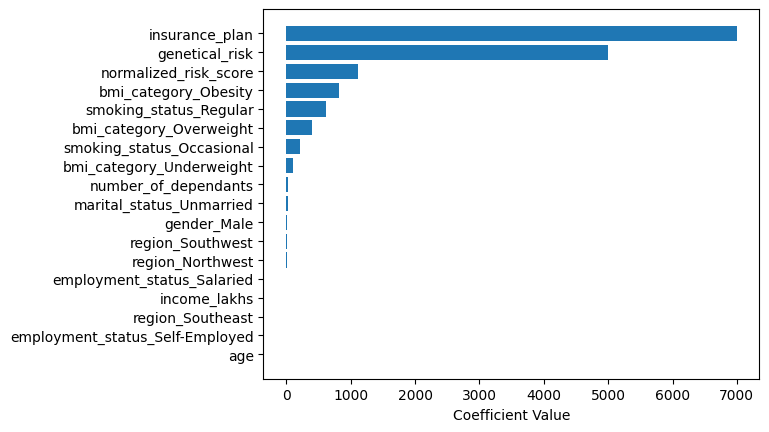

In [42]:
plt.barh(coeff_df.index, coeff_df['Coefficient'])
plt.xlabel('Coefficient Value') 
plt.show()

In [43]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)
train_score = model_rg.score(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training R^2: 0.9883, Testing R^2: 0.9887


In [44]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
train_score = model_xgb.score(X_train, y_train)
test_score = model_xgb.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training R^2: 0.9875, Testing R^2: 0.9877


In [45]:
y_pred = model_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.4f}, MSE: {mse:.4f}')

RMSE: 305.8521, MSE: 93545.5234


In [46]:
from sklearn.model_selection import RandomizedSearchCV


model_xgb = XGBRegressor()
model_params = {
    'n_estimators': [20, 40, 50],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}
random_search = RandomizedSearchCV(estimator=model_xgb, param_distributions=model_params, n_iter=10, cv=3, scoring = 'r2', random_state=42,n_jobs=-1)
random_search.fit(X_train, y_train)
print(f'Best Score: {random_search.best_score_}')
print(f'Best Parameters: {random_search.best_params_}')
best_model = random_search.best_estimator_

Best Score: 0.9879226088523865
Best Parameters: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}


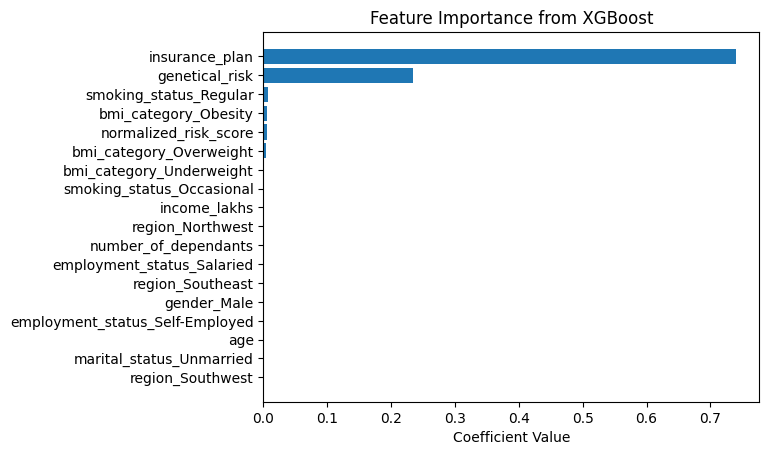

In [47]:
feature_importance = best_model.feature_importances_
coeff_df = pd.DataFrame(feature_importance, index=X_reduced.columns, columns=['Coefficient'])
coeff_df = coeff_df.sort_values(by='Coefficient', ascending= True)
plt.barh(coeff_df.index, coeff_df['Coefficient'])
plt.xlabel('Coefficient Value') 
plt.title('Feature Importance from XGBoost')
plt.show()

### Error Analysis

In [48]:
y_pred = best_model.predict(X_test)
diff = y_pred - y_test
diff_pct = (diff / y_test) * 100
error_df = pd.DataFrame({
    'Actual': y_test,   'Predicted': y_pred, 'Difference': diff, 'Difference_Pct': diff_pct })
error_df.head()


,Actual,Predicted,Difference,Difference_Pct
12774,6238,6104.117676,-133.882324,-2.146238
14758,9462,9593.652344,131.652344,1.391380
13205,5152,5619.506348,467.506348,9.074269
14278,6988,7377.886230,389.886230,5.579368
19351,4917,5109.857422,192.857422,3.922258


<Axes: xlabel='Difference_Pct', ylabel='Count'>

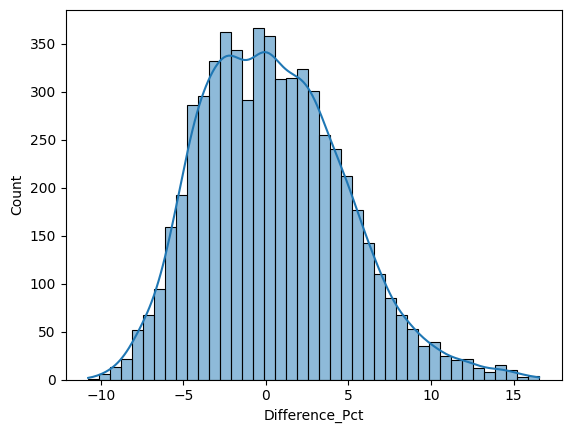

In [49]:
sns.histplot(error_df['Difference_Pct'], kde=True)

In [50]:
extreme_error_threshold = 10
df_extreme_errors = error_df[error_df['Difference_Pct'].abs() > extreme_error_threshold]
extreme_error_pct = df_extreme_errors.shape[0]/error_df.shape[0]*100
print(f'Percentage of predictions with more than {extreme_error_threshold}% error: {extreme_error_pct:.2f}%')

Percentage of predictions with more than 10% error: 2.49%


In [51]:
error_df[error_df['Difference_Pct'].abs() > 50].sort_values(by='Difference_Pct', ascending=False)

,Actual,Predicted,Difference,Difference_Pct


In [52]:
extreme_errors_data = X_test.loc[df_extreme_errors.index]

In [53]:
extreme_errors_data.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
12669,0.857143,0.000000,0.000000,0.0,0.0,0.0,1,0,1,0,1,0,1,0,0,0,1,0
2918,0.285714,0.000000,0.151515,0.0,0.2,0.0,1,1,0,0,1,0,0,0,0,0,1,0
17084,1.000000,0.000000,0.353535,0.0,0.0,0.0,1,0,0,0,1,0,0,0,0,0,0,0
7181,0.571429,0.000000,0.161616,0.0,0.0,0.0,1,0,0,1,1,0,0,0,0,0,0,0
12285,0.428571,0.333333,0.232323,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0


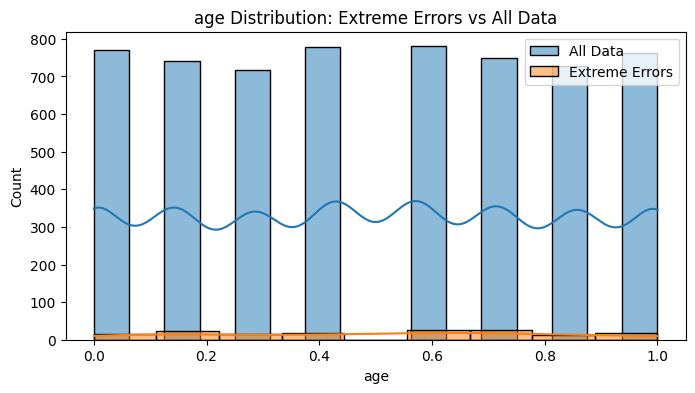

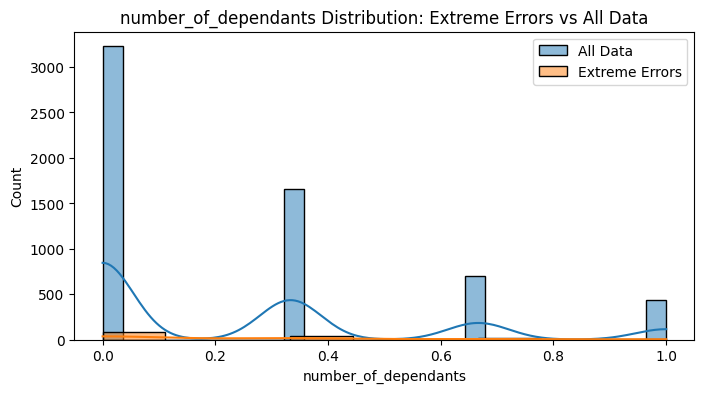

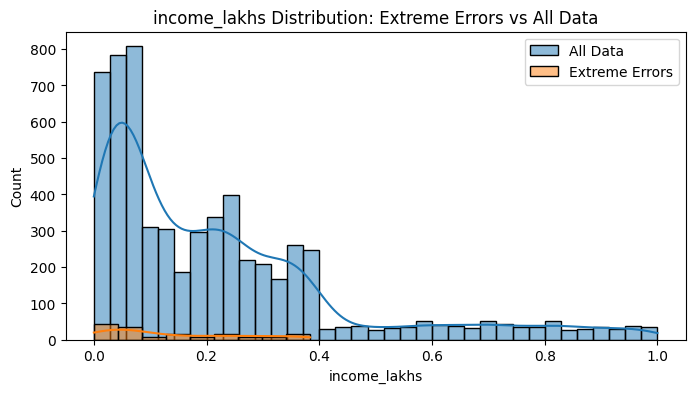

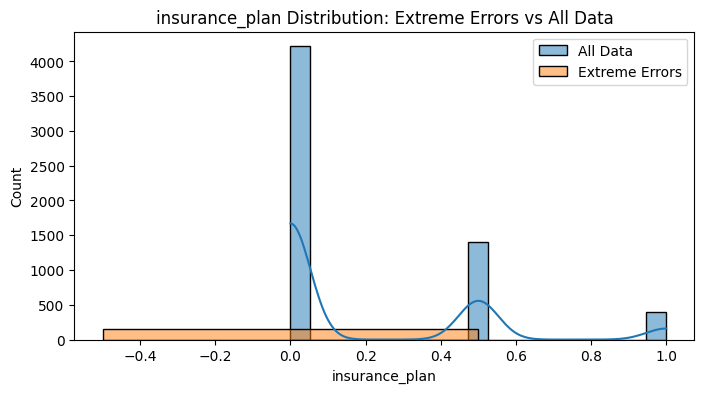

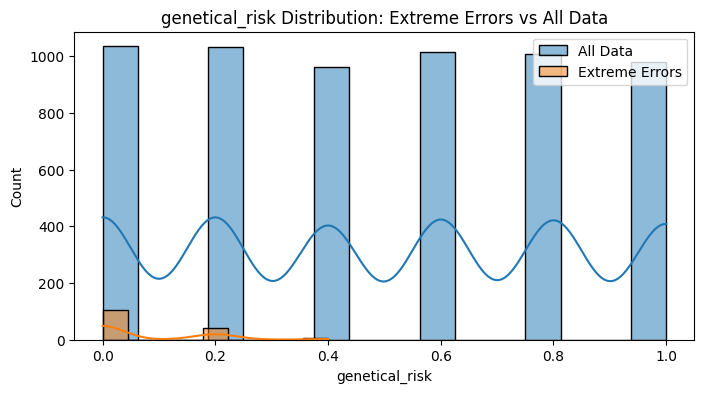

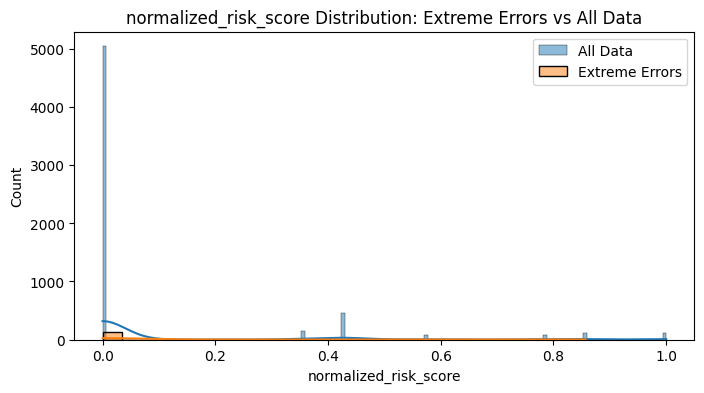

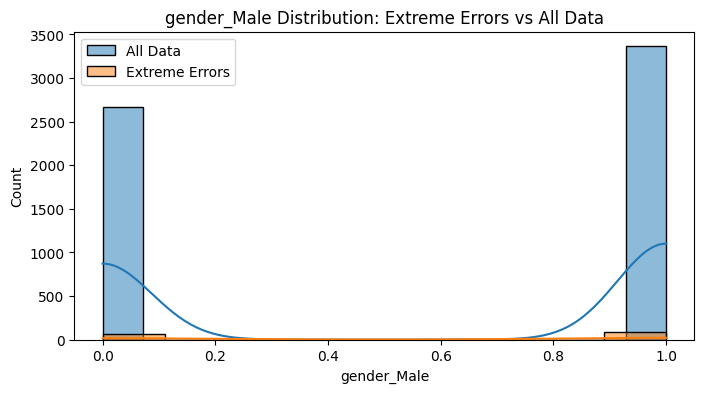

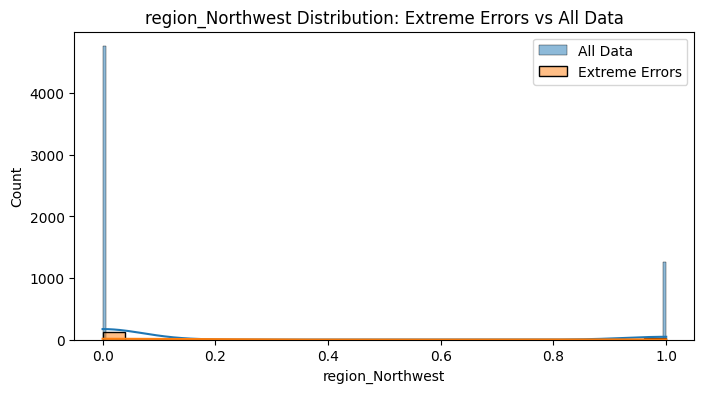

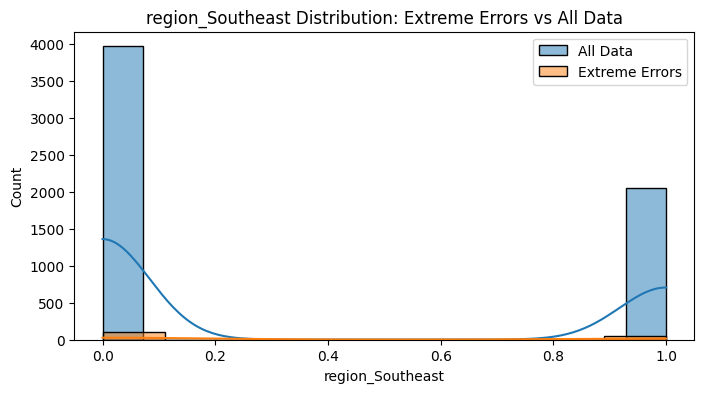

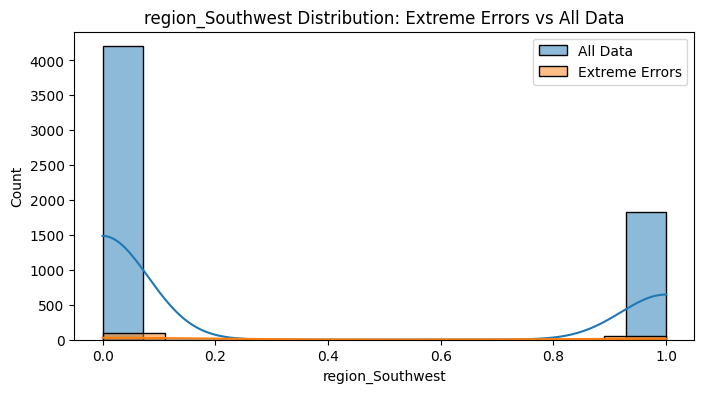

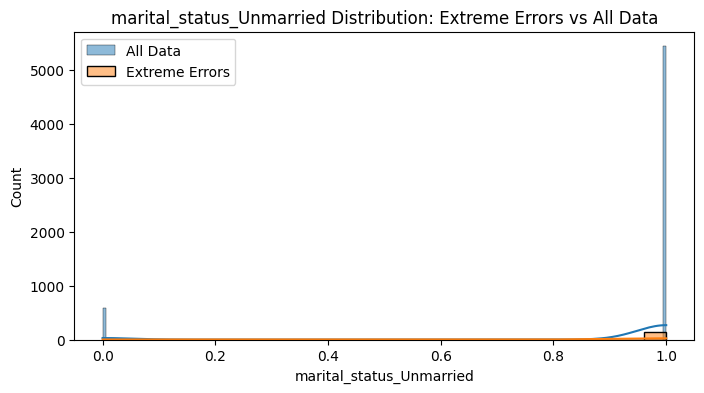

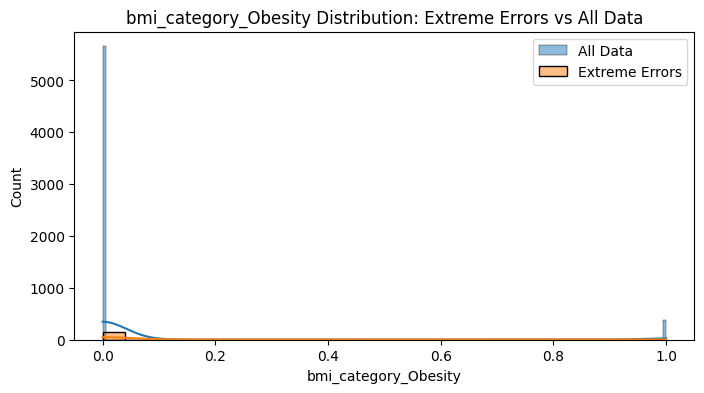

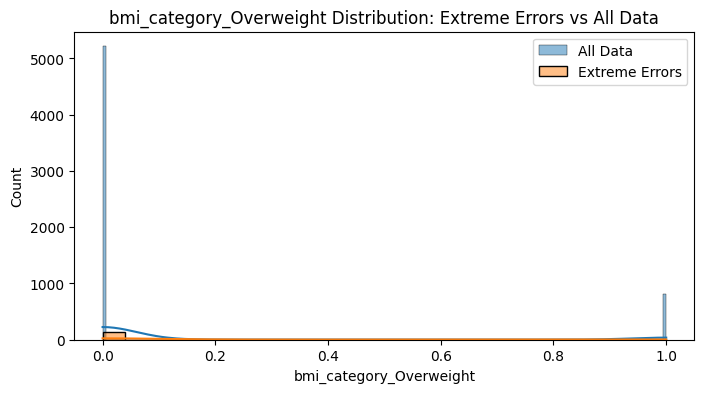

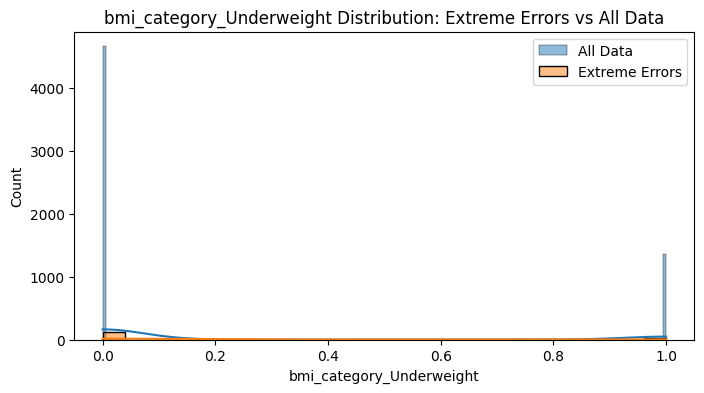

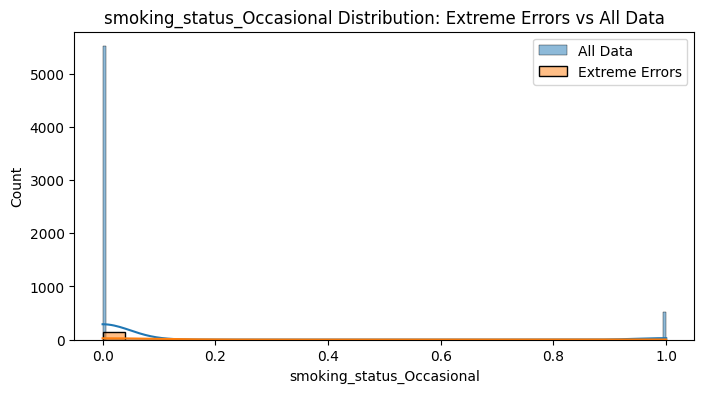

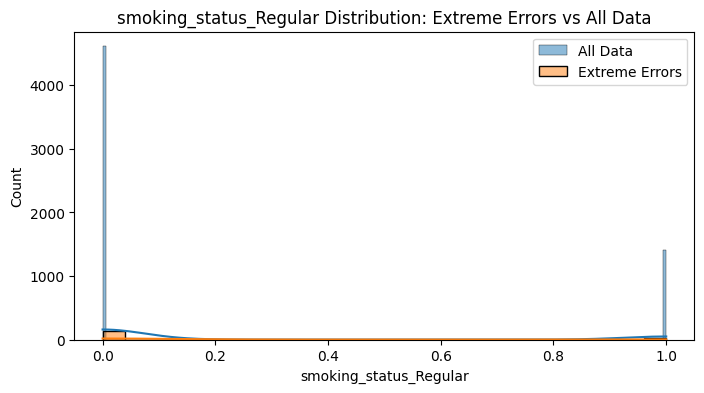

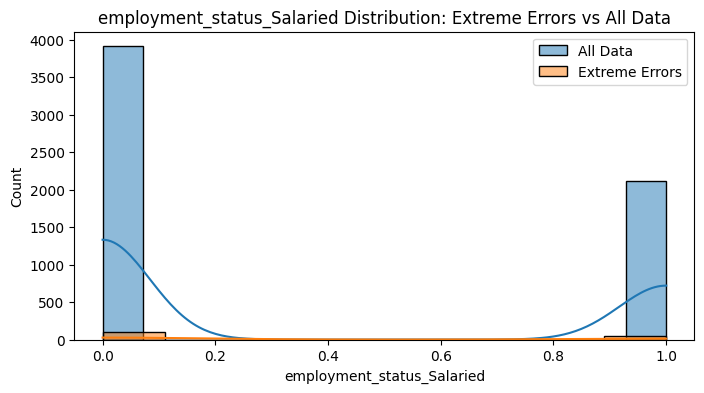

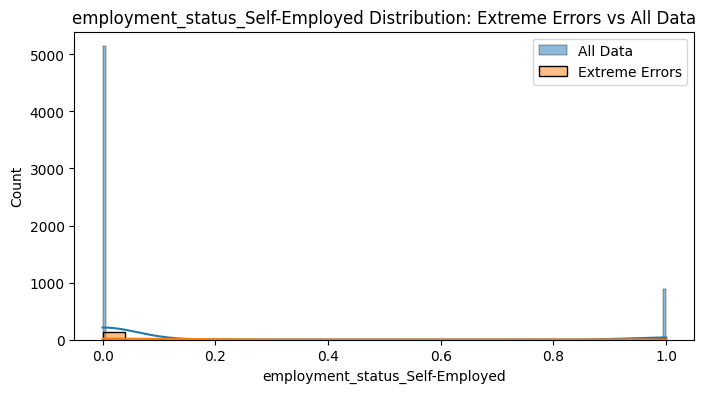

In [54]:
for feature in X_test.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_test[feature], label = "All Data", kde=True)
    sns.histplot(extreme_errors_data[feature],label = "Extreme Errors", kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: Extreme Errors vs All Data')
    plt.show()


In [55]:
extreme_errors_data['income_level'] = 0
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_data[cols_to_scale])

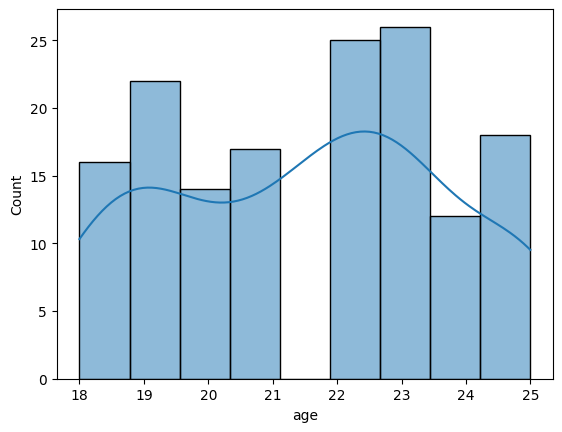

In [56]:
df_reversed.head()
sns.histplot(df_reversed['age'], kde=True)
plt.show()

In [57]:
df_reversed.age.quantile([0.97])

0.97    25.0
Name: age, dtype: float64

In [60]:
import joblib as jb
jb.dump(model, 'artifacts/model_young.joblib')

['artifacts/model_young.joblib']

In [61]:
scaler_young = { 'scaler': scaler, 'cols_to_scale': cols_to_scale }
jb.dump(scaler_young, 'artifacts/scaler_young.joblib')

['artifacts/scaler_young.joblib']